# Capítulo 37 — Comunicar resultados con visualizaciones claras

## No alcanza con hacer un gráfico

En los capítulos anteriores aprendimos a construir distintos tipos de gráficos: histogramas, boxplots, gráficos de barras, gráficos de dispersión, líneas de tendencia y mapas de calor. Cada uno nos ayudó a responder una pregunta diferente sobre los datos.

Ahora vamos a trabajar sobre otro aspecto importante del análisis de datos: la comunicación visual. Un gráfico no solo debe existir; también debe poder leerse con claridad. Para eso necesitamos tomar decisiones sobre el título, los ejes, el orden de las categorías, los colores, el tamaño de la figura y el tipo de gráfico elegido.

En este capítulo vamos a revisar cómo mejorar visualizaciones para que comuniquen mejor una idea. No se trata de decorar los gráficos, sino de hacerlos más claros, más precisos y más útiles para quien los lee.

Vamos a seguir usando el dataset `tips`, porque ya conocemos sus columnas y eso nos permite concentrarnos en la forma de comunicar los resultados.

## Cargar el dataset

Como en los capítulos anteriores, primero importamos las librerías necesarias y cargamos el dataset `tips`.

Después vamos a construir algunos gráficos y revisar cómo pequeñas decisiones pueden mejorar su lectura.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


La salida muestra las primeras filas del dataset `tips`. Como ya vimos, cada fila representa una cuenta registrada en un restaurante, con información sobre el importe total, la propina, el día, el horario, el tamaño del grupo y algunas variables categóricas.

En este capítulo no vamos a buscar una técnica nueva de análisis, sino a mejorar la forma en que presentamos resultados. Para eso vamos a partir de una pregunta simple: ¿cuál es el promedio del importe total de la cuenta según el día?

Primero vamos a construir una tabla de resumen. Luego usaremos esa tabla para crear un gráfico y revisar qué decisiones ayudan a que sea más claro.

## Preparar un resumen para graficar

Antes de hacer el gráfico, vamos a calcular el promedio de `total_bill` para cada día. También vamos a respetar el orden temporal básico de los días registrados en el dataset: `Thur`, `Fri`, `Sat` y `Sun`.

Este paso es importante porque un gráfico claro suele empezar con una tabla clara. Si los datos que alimentan al gráfico están bien organizados, después es más fácil controlar el orden, los nombres y la interpretación visual.

In [2]:
orden_dias = ["Thur", "Fri", "Sat", "Sun"]

promedio_dia = (
    df.groupby("day", observed=True)["total_bill"]
    .mean()
    .reindex(orden_dias)
    .reset_index()
)

promedio_dia["total_bill"] = promedio_dia["total_bill"].round(2)

promedio_dia

,day,total_bill
0,Thur,17.68
1,Fri,17.15
2,Sat,20.44
3,Sun,21.41


La tabla muestra el promedio del importe total de la cuenta según el día. Los valores están redondeados a dos decimales para que sean más fáciles de leer.

Podemos observar que `Sat` y `Sun` tienen promedios más altos que `Thur` y `Fri`. Sin embargo, por ahora no vamos a concentrarnos solamente en la interpretación del resultado, sino en cómo comunicarlo visualmente de manera clara.

A continuación vamos a construir un primer gráfico de barras. Será un gráfico válido, pero todavía podemos mejorarlo.

## Primer gráfico: correcto, pero mejorable

Vamos a empezar con un gráfico de barras simple. En el eje horizontal ubicaremos los días y en el eje vertical el promedio de `total_bill`.

Este primer gráfico ya comunica la comparación general, pero después vamos a revisar qué elementos pueden mejorarse para que la lectura sea más clara.

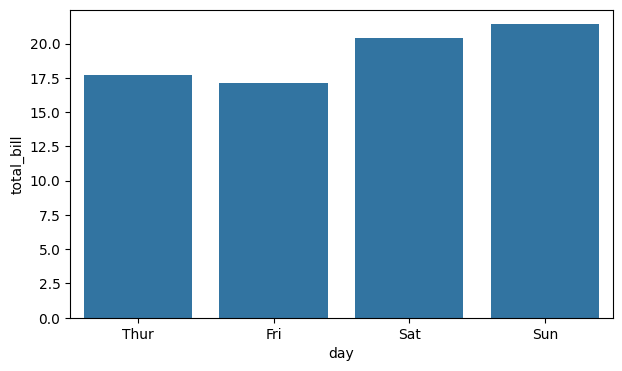

In [3]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=promedio_dia,
    x="day",
    y="total_bill"
)

plt.show()

El gráfico muestra el promedio de `total_bill` para cada día registrado en el dataset. La comparación general se entiende: `Sat` y `Sun` tienen promedios más altos, mientras que `Thur` y `Fri` tienen promedios más bajos.

Sin embargo, el gráfico todavía puede comunicar mejor. No tiene título, y los nombres de los ejes aparecen con los nombres originales de las columnas: `day` y `total_bill`. Esos nombres son útiles cuando trabajamos con código, pero pueden ser poco claros para una persona que solo está leyendo el gráfico.

Una primera mejora consiste en agregar un título descriptivo y etiquetas más claras para los ejes.

## Mejorar título y etiquetas

Un gráfico claro debería responder rápidamente tres preguntas:

- qué se está comparando;
- qué representa cada eje;
- cuál es la unidad o el significado de los valores.

Para mejorar el gráfico anterior, vamos a agregar un título y cambiar las etiquetas de los ejes por textos más descriptivos.

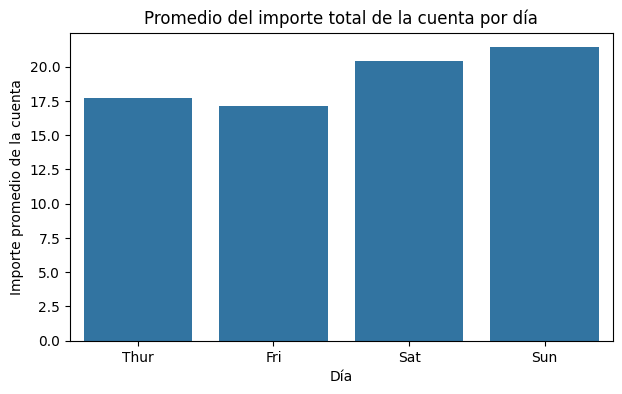

In [4]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=promedio_dia,
    x="day",
    y="total_bill"
)

plt.title("Promedio del importe total de la cuenta por día")
plt.xlabel("Día")
plt.ylabel("Importe promedio de la cuenta")

plt.show()

Este segundo gráfico comunica la misma información que el anterior, pero lo hace con más claridad. El título indica qué se está comparando, el eje horizontal dice que las categorías son días y el eje vertical explica que los valores corresponden al importe promedio de la cuenta.

Este tipo de mejora parece simple, pero es muy importante. Cuando un gráfico se comparte en un informe, una presentación o un cuaderno, no siempre va acompañado de una explicación oral. Por eso, el gráfico debería ser lo suficientemente claro como para que otra persona pueda entenderlo sin tener que revisar el código que lo generó.

Ahora vamos a agregar otra mejora: mostrar el valor exacto encima de cada barra.

## Agregar valores sobre las barras

A veces conviene mostrar los valores exactos directamente sobre el gráfico. Esto es útil cuando queremos facilitar la lectura sin obligar a la persona a estimar el valor mirando el eje vertical.

En este caso, como tenemos solo cuatro barras, podemos agregar el promedio encima de cada una sin sobrecargar demasiado la visualización.

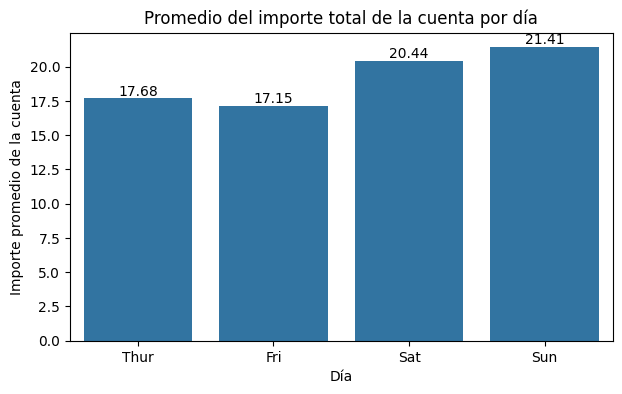

In [5]:
plt.figure(figsize=(7, 4))

grafico = sns.barplot(
    data=promedio_dia,
    x="day",
    y="total_bill"
)

plt.title("Promedio del importe total de la cuenta por día")
plt.xlabel("Día")
plt.ylabel("Importe promedio de la cuenta")

for barra in grafico.containers:
    grafico.bar_label(barra, fmt="%.2f")

plt.show()

El gráfico ahora incluye el valor exacto encima de cada barra. Esto facilita la lectura porque podemos ver directamente que los promedios son 17.68 para `Thur`, 17.15 para `Fri`, 20.44 para `Sat` y 21.41 para `Sun`.

Agregar valores puede ser útil cuando hay pocas barras y queremos comunicar cifras concretas. Sin embargo, no siempre conviene hacerlo. Si el gráfico tuviera muchas categorías, demasiadas etiquetas podrían hacerlo más difícil de leer.

En este caso, las etiquetas funcionan bien, aunque vemos que la etiqueta de `Sun` queda muy cerca del borde superior. Vamos a ajustar el límite del eje vertical para dejar un poco más de aire visual.

## Dejar espacio para las etiquetas

Cuando agregamos etiquetas sobre las barras, a veces necesitamos ajustar el eje vertical para que el texto no quede pegado al borde del gráfico.

Para eso podemos usar `plt.ylim()`, que permite definir el límite inferior y superior del eje vertical.

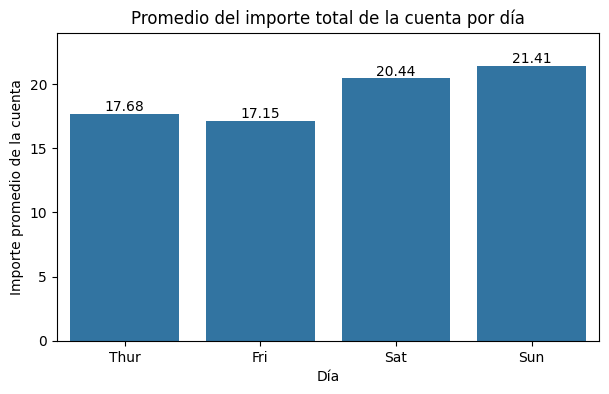

In [6]:
plt.figure(figsize=(7, 4))

grafico = sns.barplot(
    data=promedio_dia,
    x="day",
    y="total_bill"
)

plt.title("Promedio del importe total de la cuenta por día")
plt.xlabel("Día")
plt.ylabel("Importe promedio de la cuenta")
plt.ylim(0, 24)

for barra in grafico.containers:
    grafico.bar_label(barra, fmt="%.2f")

plt.show()

El ajuste del eje vertical mejora la presentación del gráfico. Al usar `plt.ylim(0, 24)`, dejamos un poco más de espacio por encima de la barra más alta, de modo que las etiquetas no quedan pegadas al borde superior.

La instrucción `plt.ylim()` permite definir los límites del eje vertical. En este caso usamos 0 como límite inferior y 24 como límite superior. Es importante que este tipo de ajuste no distorsione la lectura: el eje sigue empezando en 0, por lo que las alturas de las barras se comparan de manera clara.

También usamos `grafico.bar_label()` para agregar los valores sobre las barras. El argumento `fmt="%.2f"` indica que queremos mostrar los números con dos decimales.

## Mejorar el estilo general

Además del título, las etiquetas y los valores, podemos mejorar la lectura usando un estilo visual más limpio. Por ejemplo, una grilla suave en el fondo puede ayudar a comparar las alturas de las barras sin recargar el gráfico.

También podemos definir un color único para las barras. En este caso no necesitamos muchos colores, porque todas las barras representan el mismo indicador: el promedio del importe total de la cuenta. Usar un color uniforme ayuda a que la atención se concentre en la comparación de valores, no en diferencias de color que no significan nada especial.

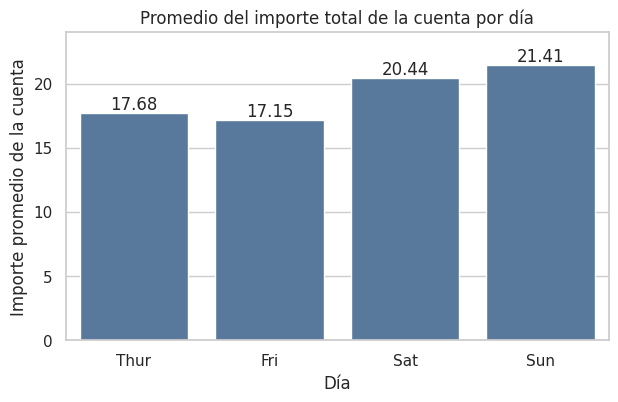

In [7]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 4))

grafico = sns.barplot(
    data=promedio_dia,
    x="day",
    y="total_bill",
    color="#4C78A8"
)

plt.title("Promedio del importe total de la cuenta por día")
plt.xlabel("Día")
plt.ylabel("Importe promedio de la cuenta")
plt.ylim(0, 24)

for barra in grafico.containers:
    grafico.bar_label(barra, fmt="%.2f")

plt.show()

El gráfico mejorado comunica la comparación con más claridad. La grilla horizontal ayuda a ubicar visualmente los valores, el color uniforme evita interpretar diferencias que no existen y las etiquetas sobre las barras permiten leer los promedios exactos.

También es importante notar que no usamos un color distinto para cada día. En este caso, todos los días forman parte de una misma comparación y representan el mismo indicador: el promedio de `total_bill`. Por eso, un solo color alcanza y evita sumar información visual innecesaria.

Este tipo de decisión forma parte de la comunicación de resultados. Un gráfico claro no necesariamente es el más llamativo, sino el que permite entender mejor la comparación que queremos mostrar.

## Ordenar según el mensaje que queremos comunicar

Hasta ahora respetamos el orden temporal básico de los días registrados: `Thur`, `Fri`, `Sat`, `Sun`. Ese orden es útil cuando queremos leer los días como una secuencia.

Pero a veces queremos comunicar otra idea. Por ejemplo, si la pregunta principal fuera “¿qué día tiene el promedio más alto?”, podría ser más claro ordenar las barras de mayor a menor.

Vamos a crear una nueva versión de la tabla, ordenada según el promedio de `total_bill`.

In [8]:
promedio_dia_ordenado = promedio_dia.sort_values(
    "total_bill",
    ascending=False
)

promedio_dia_ordenado

,day,total_bill
3,Sun,21.41
2,Sat,20.44
0,Thur,17.68
1,Fri,17.15


La tabla ahora está ordenada según el valor de `total_bill`, de mayor a menor. Este orden cambia la lectura: ya no estamos mostrando los días como una secuencia temporal básica, sino como un ranking según el promedio del importe total de la cuenta.

Ambos criterios pueden ser válidos, pero responden a preguntas distintas. Si queremos observar los días en su orden habitual dentro del dataset, conviene usar `Thur`, `Fri`, `Sat`, `Sun`. Si queremos destacar qué día tiene el promedio más alto, puede ser más claro ordenar las barras de mayor a menor.

Ahora vamos a construir el gráfico usando esta tabla ordenada.

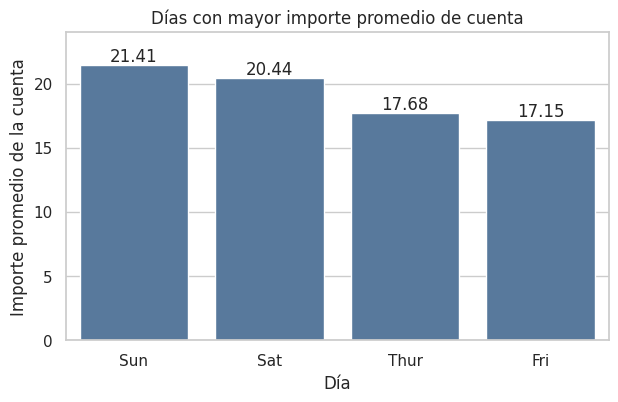

In [9]:
plt.figure(figsize=(7, 4))

grafico = sns.barplot(
    data=promedio_dia_ordenado,
    x="day",
    y="total_bill",
    color="#4C78A8"
)

plt.title("Días con mayor importe promedio de cuenta")
plt.xlabel("Día")
plt.ylabel("Importe promedio de la cuenta")
plt.ylim(0, 24)

for barra in grafico.containers:
    grafico.bar_label(barra, fmt="%.2f")

plt.show()

El gráfico ordenado de mayor a menor cambia la forma de leer la información. En lugar de seguir el orden temporal básico de los días registrados, ahora muestra un ranking según el promedio del importe total de la cuenta.

Esta versión es útil si queremos responder rápidamente cuál es el día con mayor promedio. La respuesta aparece al inicio del gráfico: `Sun`, seguido por `Sat`.

Sin embargo, este orden también tiene una desventaja: se pierde la lectura temporal básica de `Thur`, `Fri`, `Sat`, `Sun`. Por eso, el orden de las barras no es una decisión neutral. Depende de la pregunta que queremos comunicar.

Si la pregunta es “¿cómo se comportan los días en su secuencia?”, conviene mantener el orden temporal. Si la pregunta es “¿cuáles son los valores más altos?”, conviene ordenar como ranking.

## Elegir títulos según la intención

El título de un gráfico también comunica una intención. No es lo mismo titular un gráfico “Promedio del importe total de la cuenta por día” que titularlo “Días con mayor importe promedio de cuenta”.

El primer título es más descriptivo y neutral. Indica qué se está mostrando, sin orientar demasiado la lectura. El segundo título destaca una comparación de ranking: invita a mirar qué días tienen valores más altos.

Ninguna de las dos opciones es siempre mejor. La elección depende del propósito del gráfico. En un análisis exploratorio, suele convenir usar títulos descriptivos. En una presentación de resultados, puede ser útil usar títulos más orientados al mensaje, siempre que no exageren ni afirmen más de lo que muestran los datos.

## Revisar si el gráfico cuenta toda la historia

El gráfico de promedios por día es claro, pero todavía tiene una limitación: solo muestra el promedio. Como vimos en capítulos anteriores, un promedio puede ocultar diferencias importantes en la cantidad de registros, la dispersión o la presencia de valores extremos.

Por eso, cuando comunicamos resultados, también debemos preguntarnos si el gráfico elegido alcanza para sostener la interpretación. En este caso, conviene acompañar el promedio con otra información: la cantidad de cuentas registradas por día.

In [10]:
resumen_comunicacion = (
    df.groupby("day", observed=True)
    .agg(
        cantidad_cuentas=("total_bill", "count"),
        promedio_total_bill=("total_bill", "mean")
    )
    .reindex(orden_dias)
    .round(2)
    .reset_index()
)

resumen_comunicacion

,day,cantidad_cuentas,promedio_total_bill
0,Thur,62,17.68
1,Fri,19,17.15
2,Sat,87,20.44
3,Sun,76,21.41


La tabla combina dos indicadores por día: la cantidad de cuentas y el promedio de `total_bill`. Esta información ayuda a leer el gráfico anterior con más cuidado.

Por ejemplo, `Fri` tiene un promedio parecido al de `Thur`, pero tiene muchos menos registros: solo 19 cuentas. En cambio, `Sat` y `Sun` tienen más cuentas y también promedios más altos.

Cuando comunicamos resultados, este tipo de contexto es importante. Si mostramos solamente el promedio, podemos dar una imagen incompleta. Agregar la cantidad de registros permite entender mejor cuánta información sostiene cada valor.

## Mostrar dos indicadores relacionados

Hay muchas formas de mostrar dos indicadores relacionados. Una opción simple es construir dos gráficos cercanos: uno para la cantidad de cuentas y otro para el promedio del importe total.

Esta estrategia suele ser más clara que intentar poner demasiada información dentro de un solo gráfico. Si usamos dos gráficos alineados y con el mismo orden de categorías, la persona que lee puede comparar ambos indicadores sin perderse.

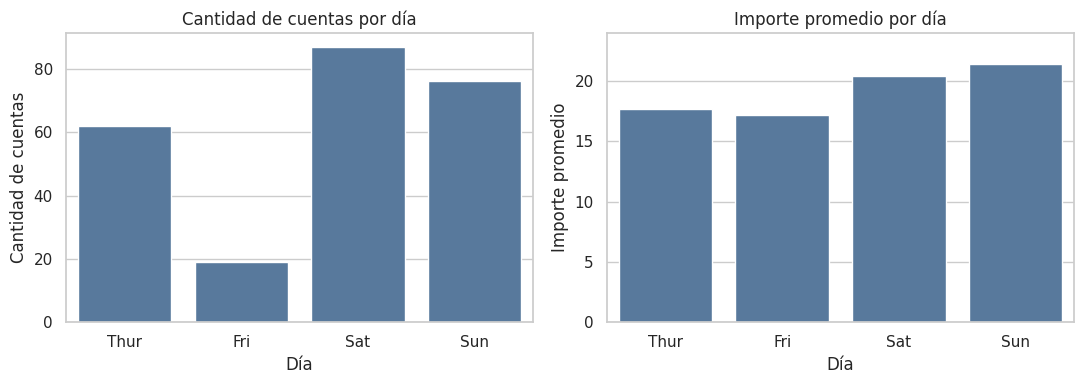

In [11]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(
    data=resumen_comunicacion,
    x="day",
    y="cantidad_cuentas",
    color="#4C78A8",
    ax=ejes[0]
)

ejes[0].set_title("Cantidad de cuentas por día")
ejes[0].set_xlabel("Día")
ejes[0].set_ylabel("Cantidad de cuentas")

sns.barplot(
    data=resumen_comunicacion,
    x="day",
    y="promedio_total_bill",
    color="#4C78A8",
    ax=ejes[1]
)

ejes[1].set_title("Importe promedio por día")
ejes[1].set_xlabel("Día")
ejes[1].set_ylabel("Importe promedio")
ejes[1].set_ylim(0, 24)

plt.tight_layout()
plt.show()

Los dos gráficos muestran información complementaria. A la izquierda vemos la cantidad de cuentas registradas por día, y a la derecha vemos el importe promedio de la cuenta para esos mismos días.

Esta comparación ayuda a evitar una lectura incompleta. Por ejemplo, `Fri` tiene un promedio parecido al de `Thur`, pero tiene muchos menos registros. En cambio, `Sat` y `Sun` tienen más cuentas y también muestran promedios más altos.

La ventaja de usar dos gráficos separados es que cada uno conserva una escala clara. La cantidad de cuentas y el importe promedio son indicadores distintos, por lo que intentar mezclarlos en un solo eje podría confundir. En cambio, al ponerlos uno al lado del otro, podemos compararlos manteniendo la lectura ordenada.

## Mejorar una figura con varios gráficos

Cuando usamos más de un gráfico en la misma figura, conviene cuidar algunos detalles adicionales. Por ejemplo, podemos agregar un título general para indicar cuál es la idea completa de la figura, mantener el mismo orden de categorías en ambos gráficos y agregar etiquetas de valores cuando no sobrecargan la visualización.

Vamos a construir una versión más pulida de la figura anterior, agregando un título general y valores sobre las barras.

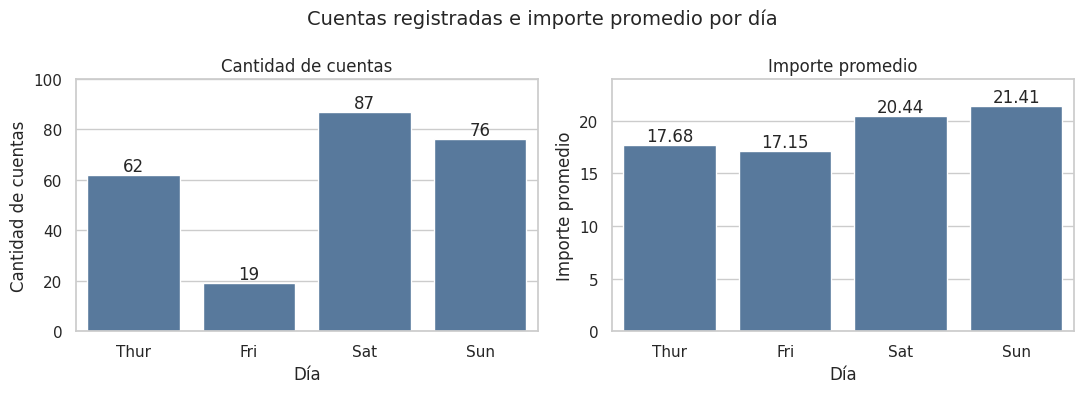

In [12]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4))

fig.suptitle("Cuentas registradas e importe promedio por día", fontsize=14)

grafico_cantidad = sns.barplot(
    data=resumen_comunicacion,
    x="day",
    y="cantidad_cuentas",
    color="#4C78A8",
    ax=ejes[0]
)

ejes[0].set_title("Cantidad de cuentas")
ejes[0].set_xlabel("Día")
ejes[0].set_ylabel("Cantidad de cuentas")
ejes[0].set_ylim(0, 100)

for barras in grafico_cantidad.containers:
    grafico_cantidad.bar_label(barras, fmt="%.0f")

grafico_promedio = sns.barplot(
    data=resumen_comunicacion,
    x="day",
    y="promedio_total_bill",
    color="#4C78A8",
    ax=ejes[1]
)

ejes[1].set_title("Importe promedio")
ejes[1].set_xlabel("Día")
ejes[1].set_ylabel("Importe promedio")
ejes[1].set_ylim(0, 24)

for barras in grafico_promedio.containers:
    grafico_promedio.bar_label(barras, fmt="%.2f")

plt.tight_layout()
plt.show()

La figura final integra dos indicadores relacionados sin mezclarlos en un único gráfico. A la izquierda vemos cuántas cuentas hay por día, y a la derecha vemos el importe promedio de esas cuentas.

Esta presentación ayuda a leer el promedio con más contexto. Por ejemplo, `Fri` tiene un promedio cercano al de `Thur`, pero está basado en muchos menos registros. En cambio, `Sat` y `Sun` tienen más cuentas y también importes promedio más altos.

También se puede observar que las etiquetas de valores funcionan bien porque hay pocas barras. Si tuviéramos muchas categorías, quizá sería mejor no mostrar todos los valores sobre el gráfico y dejar esa información en una tabla complementaria.

## Usar color para destacar, no para decorar

El color puede ayudar mucho a comunicar una idea, pero conviene usarlo con intención. Si cada barra tiene un color diferente sin que eso represente una variable o un mensaje, el gráfico puede volverse más confuso.

Una estrategia útil es usar un color general para casi todos los elementos y destacar solo aquello que queremos señalar. Por ejemplo, si queremos resaltar el día con mayor importe promedio, podemos usar un color diferente para `Sun` y dejar el resto de las barras en un tono más neutro.

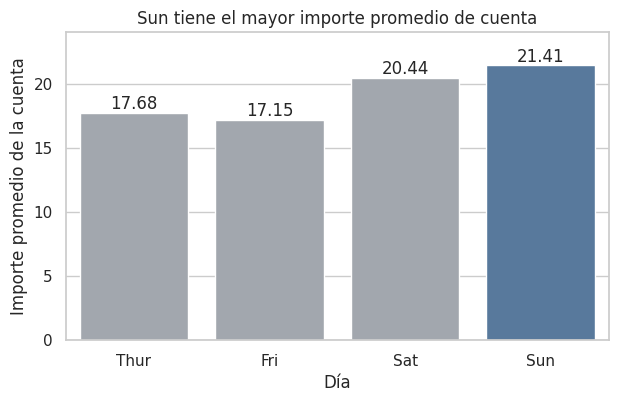

In [13]:
colores = [
    "#A0A7B0" if dia != "Sun" else "#4C78A8"
    for dia in promedio_dia["day"]
]

plt.figure(figsize=(7, 4))

grafico = sns.barplot(
    data=promedio_dia,
    x="day",
    y="total_bill",
    palette=colores,
    hue="day",
    legend=False
)

plt.title("Sun tiene el mayor importe promedio de cuenta")
plt.xlabel("Día")
plt.ylabel("Importe promedio de la cuenta")
plt.ylim(0, 24)

for barra in grafico.containers:
    grafico.bar_label(barra, fmt="%.2f")

plt.show()

En este gráfico usamos el color para destacar un mensaje específico: `Sun` tiene el mayor importe promedio de cuenta. Las barras de `Thur`, `Fri` y `Sat` aparecen en gris, mientras que `Sun` aparece en azul. Esto hace que la atención vaya rápidamente hacia el valor que queremos señalar.

Esta decisión funciona porque el color tiene una intención clara. No estamos usando colores diferentes para decorar, sino para marcar una comparación concreta. Aun así, el gráfico conserva los demás valores, por lo que la persona que lo lee puede ver que `Sat` también tiene un promedio alto y que la diferencia entre `Sat` y `Sun` no es enorme.

Este punto es importante: destacar un dato no debería ocultar el resto de la información ni exagerar la diferencia entre valores.

## Cómo se definieron los colores

En la celda anterior creamos una lista de colores antes de construir el gráfico.

La parte principal fue:

```python
colores = [
    "#A0A7B0" if dia != "Sun" else "#4C78A8"
    for dia in promedio_dia["day"]
]
```

Esta instrucción recorre los días de la tabla `promedio_dia`. Si el día no es `Sun`, asigna un color gris. Si el día es `Sun`, asigna un color azul.

Después usamos esa lista en `sns.barplot()` mediante el argumento `palette=colores`.

También usamos `hue="day"` y `legend=False`. En versiones recientes de Seaborn, cuando queremos aplicar una paleta personalizada a categorías, conviene indicar explícitamente la variable categórica con `hue`. Como en este caso el color solo se usa para destacar las barras y no necesitamos una leyenda adicional, usamos `legend=False`.

## No exagerar el mensaje

Cuando comunicamos resultados, es tentador escribir títulos muy fuertes. Por ejemplo, podríamos titular el gráfico: “El domingo es claramente el mejor día”. Pero ese título sería problemático, porque el gráfico solo muestra el importe promedio de las cuentas en este dataset.

Una opción más prudente es usar un título que diga exactamente lo que el gráfico permite sostener: `Sun tiene el mayor importe promedio de cuenta`. Ese título comunica el hallazgo principal, pero no agrega interpretaciones que no están en los datos.

En análisis de datos, una buena visualización no solo debe ser clara. También debe ser honesta con el alcance de la información disponible.

## Cierre del capítulo

En este capítulo trabajamos sobre la comunicación visual de resultados. Partimos de un gráfico correcto pero básico, y fuimos agregando mejoras: título, etiquetas de ejes, valores sobre las barras, ajuste del eje vertical, estilo visual, orden de categorías, figuras con más de un gráfico y uso intencional del color.

También vimos que cada decisión debe responder a una intención. Ordenar las barras como ranking puede ser útil si queremos destacar los valores más altos, pero no siempre conviene si necesitamos respetar una secuencia temporal. Agregar etiquetas puede ayudar cuando hay pocas barras, pero puede recargar el gráfico si hay demasiadas categorías. Usar color puede guiar la lectura, siempre que no se use solo como decoración.

La idea central del capítulo es que comunicar con gráficos no consiste solamente en generar una imagen. Consiste en construir una visualización que ayude a entender mejor una pregunta, sin ocultar contexto ni exagerar conclusiones.

En el próximo capítulo vamos a avanzar hacia una etapa de cierre del bloque de análisis exploratorio, integrando varias herramientas trabajadas hasta ahora.